# Ground Condition Predictor v2 — Enhanced Model

**What's new vs v1:**
- Session-level pressure & impact normalisation (removes shoe/body-weight offset)
- Ratio features instead of raw magnitudes (body-weight invariant)
- Temporal heel-curve shape features: time-to-peak, impulse, rise/fall slope asymmetry, skewness, kurtosis
- Gyroscope features at heel strike and across stance (ankle stability)
- Step-to-step rolling consistency features (surface texture signal)
- Sequence smoothing post-processing (majority vote over 5-step window)
- **Composite score** combining Accuracy + Macro F1 + Brick F1

**Surface mapping:**

| Raw label | Class |
|---|---|
| grass, compact ground, dirt | `grass` |
| brick | `brick` |
| concrete, asphalt, exposed aggregate | `concrete` |

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew, kurtosis as scipy_kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
import os

# ── Sensor groups ─────────────────────────────────────────────────────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]

# ── Algorithm parameters ──────────────────────────────────────────────
SMOOTH_WIN=11; SMOOTH_POLY=2; PEAK_DIST=50; PEAK_PROM=200; PEAK_HT=500
SAMPLING_HZ=62.5; HILL_WIN=10; MIN_DP=5

# ── Surface normalisation map ─────────────────────────────────────────
SURFACE_MAP = {
    'grass': 'grass', 'compact ground': 'grass', 'dirt': 'grass',
    'brick': 'brick',
    'concrete': 'concrete', 'asphalt': 'concrete', 'exposed aggregate': 'concrete',
}
BASE_COLS = set(
    ['sole_id','timestamp','accel_x','accel_y','accel_z',
     'gyro_x','gyro_y','gyro_z','magn_x','magn_y','magn_z','corrupt']
    + [f'pressure_{i:02d}' for i in range(1,13)]
)
SURFACE_COLORS = {'grass':'#4CAF50','brick':'#E64A19','concrete':'#607D8B','unknown':'#9E9E9E'}

# ── Composite score weights ───────────────────────────────────────────
# Rewards balanced performance across all classes, with extra weight on
# Brick (hardest class to separate from Concrete)
W_ACC=0.30; W_MACRO_F1=0.50; W_BRICK_F1=0.20

# ── Data paths ────────────────────────────────────────────────────────
ORIGINAL_CSVS = {'grass':'grass_dry.csv','brick':'brick_dry.csv','concrete':'concrete_dry.csv'}
REC_DIR = '.'   # folder containing REC_*.csv files
print('Ready.')

Ready.


## 1. Core Functions

In [2]:
def get_surface_cols(df):
    return [c for c in df.columns if c not in BASE_COLS and c in SURFACE_MAP]


def label_surface_segments(df):
    """
    Parse 'x' markers in extra columns to label each row with a surface.
    Each marker indicates the START of that surface type.
    """
    surf_cols = get_surface_cols(df)
    if not surf_cols: return None
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    events = []
    for col in surf_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]:
            events.append((int(idx), SURFACE_MAP[col]))
    if not events: return None
    events.sort()
    df['surface'] = None
    for i, (start_idx, surf) in enumerate(events):
        end_idx = events[i+1][0] if i+1 < len(events) else len(df)
        df.loc[start_idx:end_idx-1, 'surface'] = surf
    return df[df['surface'].notna()].copy()


def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df


def find_step_windows(df):
    y_comb = sum(
        pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(dtype=float)
        for s in HEEL_SENSORS if s in df.columns
    )
    n=len(y_comb); sw=min(SMOOTH_WIN, n-(0 if n%2==1 else 1))
    if sw%2==0: sw-=1
    if sw<=SMOOTH_POLY: sw=SMOOTH_POLY+3+(1 if (SMOOTH_POLY+3)%2==0 else 0)
    y_sm = savgol_filter(y_comb, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))
    peaks, _ = find_peaks(y_sm, distance=PEAK_DIST, prominence=PEAK_PROM, height=PEAK_HT)
    return peaks


def compute_session_stats(df):
    """
    Compute session-level normalisation anchors from the full raw recording.
    Used to remove shoe/body-weight offsets between sessions.
    """
    total_p = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    accel_y = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    valid   = total_p[total_p > 0]
    return {
        'total_p_mean': float(np.mean(valid)) if len(valid) else 1.0,
        'total_p_std':  float(np.std(valid))  if len(valid) else 1.0,
        'impact_mean':  float(np.mean(np.abs(accel_y))),
        'impact_std':   float(np.std(np.abs(accel_y))) + 1e-9,
    }


print('Helper functions defined.')

Helper functions defined.


In [3]:
def extract_step_features(df, surface_label='unknown', foot_label='unknown', session_stats=None):
    """
    Extract enhanced per-step feature set.

    Feature groups:
    - Timing:          stance_duration, time_to_peak_frac
    - Impact:          impact_mag (raw + session-normalised), accel_mag_strike
    - Loading rate:    loading_rate (raw + session-normalised)
    - Pressure ratios: heel/fore pmax and mean as fraction of total (body-weight invariant)
    - Heel curve shape: impulse, rise/fall slope, asymmetry, skewness, kurtosis
    - Midstance:       heel-forefoot balance at midstance
    - Gyroscope:       magnitude & axes at heel strike, std across stance
    - Consistency:     rolling 3-step std of impact, loading rate, stance duration
    - Per-sensor:      mean of each of 12 sensors normalised by total pressure
    """
    df = df.copy().reset_index(drop=True)
    t         = df['time_sec'].values
    heel_sig  = df[HEEL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    fore_sig  = df[FOREFOOT_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    heel_norm = heel_sig / len(HEEL_SENSORS)
    fore_norm = fore_sig / len(FOREFOOT_SENSORS)
    accel_y   = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    accel_x   = pd.to_numeric(df['accel_x'], errors='coerce').fillna(0).values
    accel_z   = pd.to_numeric(df['accel_z'], errors='coerce').fillna(0).values
    gyro_x    = pd.to_numeric(df['gyro_x'],  errors='coerce').fillna(0).values
    gyro_y    = pd.to_numeric(df['gyro_y'],  errors='coerce').fillna(0).values
    gyro_z    = pd.to_numeric(df['gyro_z'],  errors='coerce').fillna(0).values
    total_p   = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values

    if session_stats is None:
        session_stats = compute_session_stats(df)

    peaks = find_step_windows(df)
    if len(peaks) < 2: return pd.DataFrame()

    rows = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        wh=heel_sig[p1:p2]; wf=fore_sig[p1:p2]
        whn=heel_norm[p1:p2]; wfn=fore_norm[p1:p2]
        way=accel_y[p1:p2]; wax=accel_x[p1:p2]; waz=accel_z[p1:p2]
        wgx=gyro_x[p1:p2]; wgy=gyro_y[p1:p2]; wgz=gyro_z[p1:p2]
        wtp=total_p[p1:p2]; wt=t[p1:p2]
        if len(wh) < MIN_DP: continue

        n_win  = len(wh)
        c_loc  = int(np.argmin(wh))
        diff   = np.abs(whn[c_loc:] - wfn[c_loc:])
        m_loc  = c_loc + int(np.argmin(diff))
        hw     = min(int(0.15 * SAMPLING_HZ), n_win - 1)
        impact = float(np.max(np.abs(way[max(0,c_loc-hw):c_loc+hw+1])))

        # Loading rate
        lr_vals = []
        for s in HEEL_SENSORS:
            if s not in df.columns: continue
            sy=pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
            hlo=int(np.argmin(sy)); seg=sy[hlo:min(hlo+HILL_WIN,len(sy))]
            if len(seg)<2: continue
            lp,_=find_peaks(seg,prominence=1)
            hhi=lp[0] if len(lp) else int(np.argmax(seg[1:]))+1
            rise=float(sy[hlo+hhi]-sy[hlo]); dt_lr=hhi/SAMPLING_HZ
            if dt_lr>0 and rise>MIN_DP: lr_vals.append(rise/dt_lr)
        lr = float(np.mean(lr_vals)) if lr_vals else 0.0

        # Surface label from within-step majority
        step_surf = surface_label
        if 'surface' in df.columns:
            step_surfs = df['surface'].iloc[p1:p2].dropna()
            if len(step_surfs): step_surf = step_surfs.mode()[0]

        stance_dur     = float(wt[-1]-wt[0]) if len(wt)>1 else 0.0
        total_p_mean_s = float(np.mean(wtp)) if len(wtp) else 1.0
        norm_denom     = max(total_p_mean_s, 1.0)
        total_pmax     = float(np.max(wtp)) if len(wtp) else 0.0
        heel_pmax_v    = float(np.max(wh))
        fore_pmax_v    = float(np.max(wf))
        heel_mean_v    = float(np.mean(wh))
        fore_mean_v    = float(np.mean(wf))

        # Heel curve temporal shape
        peak_idx_h     = int(np.argmax(wh))
        time_to_peak_f = peak_idx_h / max(n_win-1, 1)
        heel_impulse   = float(np.trapezoid(wh)) / max(n_win, 1)
        rise_slope     = (wh[peak_idx_h] - wh[0]) / max(peak_idx_h, 1)
        tail           = wh[peak_idx_h:]
        fall_slope     = (tail[-1]-tail[0]) / max(len(tail)-1,1) if len(tail)>1 else 0.0
        slope_asym     = rise_slope - abs(fall_slope)
        heel_skew_v    = float(skew(wh)) if len(wh)>2 else 0.0
        heel_kurt_v    = float(scipy_kurtosis(wh)) if len(wh)>3 else 0.0

        # Session-normalised impact and loading rate
        impact_norm = (impact - session_stats['impact_mean']) / session_stats['impact_std']
        lr_norm     = lr / max(session_stats['total_p_mean'], 1.0)

        # Gyroscope at heel strike
        gyro_sl  = slice(max(0,c_loc-hw), min(c_loc+hw+1, n_win))
        gx_s     = float(np.max(np.abs(wgx[gyro_sl]))) if len(wgx[gyro_sl]) else 0.0
        gy_s     = float(np.max(np.abs(wgy[gyro_sl]))) if len(wgy[gyro_sl]) else 0.0
        gz_s     = float(np.max(np.abs(wgz[gyro_sl]))) if len(wgz[gyro_sl]) else 0.0
        gyro_mag = float(np.sqrt(gx_s**2 + gy_s**2 + gz_s**2))

        # Resultant acceleration at strike
        accel_mag_s = float(np.max(
            np.sqrt(wax**2+way**2+waz**2)[max(0,c_loc-hw):c_loc+hw+1]
        )) if n_win > 0 else 0.0

        row = {
            'foot': foot_label, 'step_id': i, 'surface': step_surf,
            'contact_time_sec':   float(wt[0]) if len(wt) else 0.0,
            # Timing
            'stance_duration':    stance_dur,
            'time_to_peak_frac':  time_to_peak_f,
            # Impact
            'impact_mag':         impact,
            'impact_mag_norm':    impact_norm,
            'accel_mag_strike':   accel_mag_s,
            # Loading
            'loading_rate':       lr,
            'loading_rate_norm':  lr_norm,
            # Pressure ratios (body-weight invariant)
            'heel_pmax_ratio':    heel_pmax_v / max(total_pmax, 1.0),
            'fore_pmax_ratio':    fore_pmax_v / max(total_pmax, 1.0),
            'heel_mean_ratio':    heel_mean_v / norm_denom,
            'fore_mean_ratio':    fore_mean_v / norm_denom,
            'heel_fore_ratio':    heel_mean_v / (fore_mean_v + 1e-9),
            'total_pmax':         total_pmax,
            'total_p_mean':       total_p_mean_s,
            'midstance_diff':     float(whn[m_loc]-wfn[m_loc]) if m_loc<len(whn) else 0.0,
            # Heel curve shape
            'heel_impulse':       heel_impulse,
            'heel_impulse_norm':  heel_impulse / norm_denom,
            'rise_slope':         rise_slope,
            'fall_slope':         fall_slope,
            'slope_asym':         slope_asym,
            'heel_skew':          heel_skew_v,
            'heel_kurt':          heel_kurt_v,
            # Gyro
            'gyro_mag_strike':    gyro_mag,
            'gyro_x_strike':      gx_s,
            'gyro_y_strike':      gy_s,
            'gyro_z_strike':      gz_s,
            'gyro_x_std':         float(np.std(wgx)),
            'gyro_y_std':         float(np.std(wgy)),
            'gyro_z_std':         float(np.std(wgz)),
        }
        # Per-sensor normalised means
        for s in ALL_SENSORS:
            if s in df.columns:
                seg_s = pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
                row[f'{s}_mean_ratio'] = float(np.mean(seg_s)) / norm_denom
        rows.append(row)

    result = pd.DataFrame(rows)
    # Step-to-step rolling consistency (3-step window std)
    if len(result) >= 3:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = result[col].rolling(3, min_periods=1).std().fillna(0)
    else:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = 0.0
    return result


def rolling_majority(series, window=5):
    """Smooth per-step predictions with a majority vote over a sliding window."""
    smoothed = series.copy()
    for i in range(len(series)):
        w = series.iloc[max(0, i-window//2):min(len(series), i+window//2+1)]
        smoothed.iloc[i] = w.mode()[0]
    return smoothed


def composite_score(acc, macro_f1, brick_f1):
    """
    Single scalar summary of model quality.
    Rewards accuracy (30%), balanced class performance (50%), and
    performance on the hardest class — brick (20%).
    """
    return W_ACC * acc + W_MACRO_F1 * macro_f1 + W_BRICK_F1 * brick_f1


print('Feature extraction functions defined.')

Feature extraction functions defined.


## 2. Load & Label All Data

In [4]:
all_frames = []

# Original project CSVs (full file = one surface)
print('Loading original project CSVs...')
for surface_label, csv_path in ORIGINAL_CSVS.items():
    if not os.path.exists(csv_path):
        print(f'  [SKIP] {csv_path} not found')
        continue
    raw = pd.read_csv(csv_path, low_memory=False)
    ss  = compute_session_stats(raw)
    for sole_id, foot in [(1,'right'), (2,'left')]:
        sub = preprocess(raw[raw['sole_id'] == sole_id])
        feats = extract_step_features(sub, surface_label=surface_label,
                                      foot_label=foot, session_stats=ss)
        if len(feats):
            all_frames.append(feats)
            print(f'  {csv_path} [{foot}]: {len(feats)} steps')

# New REC_* files with embedded surface markers
print('\nLoading REC_* files...')
rec_files = sorted([f for f in os.listdir(REC_DIR)
                    if f.startswith('REC_') and f.endswith('.csv')])
for fname in rec_files:
    raw = pd.read_csv(os.path.join(REC_DIR, fname), low_memory=False)
    ss  = compute_session_stats(raw)
    file_steps = 0
    for sole_id, foot in [(1,'right'), (2,'left')]:
        sub = raw[raw['sole_id'] == sole_id].copy()
        labelled = label_surface_segments(sub)
        if labelled is None or len(labelled) == 0: continue
        labelled = preprocess(labelled)
        feats = extract_step_features(labelled, foot_label=foot, session_stats=ss)
        if len(feats):
            all_frames.append(feats)
            file_steps += len(feats)
    print(f'  {fname}: {file_steps} steps')

full_df = pd.concat(all_frames, ignore_index=True)
print(f'\nTotal steps: {len(full_df)}')
print('Surface distribution:')
print(full_df['surface'].value_counts().to_string())

Loading original project CSVs...
  grass_dry.csv [right]: 20 steps
  grass_dry.csv [left]: 20 steps
  brick_dry.csv [right]: 21 steps
  brick_dry.csv [left]: 20 steps
  concrete_dry.csv [right]: 28 steps
  concrete_dry.csv [left]: 29 steps

Loading REC_* files...
  REC_20260515_154900.csv: 313 steps
  REC_20260515_155937.csv: 340 steps
  REC_20260519_154547.csv: 184 steps
  REC_20260519_155015.csv: 507 steps
  REC_20260519_155900.csv: 614 steps
  REC_20260519_161001.csv: 666 steps
  REC_20260520_194247.csv: 248 steps
  REC_20260520_200710.csv: 630 steps
  REC_20260810_145528.csv: 959 steps

Total steps: 4599
Surface distribution:
surface
concrete    2325
brick       1318
grass        956


## 3. Prepare Feature Matrix

In [5]:
META_COLS    = ['foot', 'step_id', 'surface', 'contact_time_sec']
FEATURE_COLS = [c for c in full_df.columns if c not in META_COLS]

train_df  = full_df.dropna(subset=['surface']).copy()
X_tr      = train_df[FEATURE_COLS].fillna(0).values
y_tr      = train_df['surface'].values
le        = LabelEncoder()
y_tr_enc  = le.fit_transform(y_tr)
classes   = le.classes_
brick_idx = list(classes).index('brick')

print(f'Feature matrix: {X_tr.shape[0]} steps × {X_tr.shape[1]} features')
print(f'Classes: {classes}')
print(f'Class counts: {dict(zip(*np.unique(y_tr, return_counts=True)))}')

Feature matrix: 4599 steps × 44 features
Classes: ['brick' 'concrete' 'grass']
Class counts: {'brick': np.int64(1318), 'concrete': np.int64(2325), 'grass': np.int64(956)}


## 4. Train & Compare: Random Forest vs XGBoost

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Forest ─────────────────────────────────────────────────────
rf_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
y_cv_rf  = cross_val_predict(rf_pipe, X_tr, y_tr, cv=cv)
acc_rf   = accuracy_score(y_tr, y_cv_rf)
f1_rf    = f1_score(y_tr, y_cv_rf, labels=classes, average=None)
mf1_rf   = float(np.mean(f1_rf))
cs_rf    = composite_score(acc_rf, mf1_rf, f1_rf[brick_idx])
print(f'Random Forest  — Accuracy: {acc_rf*100:.1f}%  MacroF1: {mf1_rf*100:.1f}%  Composite: {cs_rf*100:.1f}%')

# ── XGBoost ───────────────────────────────────────────────────────────
xgb_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0
    ))
])
y_cv_xgb        = cross_val_predict(xgb_pipe, X_tr, y_tr_enc, cv=cv)
y_cv_xgb_labels = le.inverse_transform(y_cv_xgb)
acc_xgb  = accuracy_score(y_tr, y_cv_xgb_labels)
f1_xgb   = f1_score(y_tr, y_cv_xgb_labels, labels=classes, average=None)
mf1_xgb  = float(np.mean(f1_xgb))
cs_xgb   = composite_score(acc_xgb, mf1_xgb, f1_xgb[brick_idx])
print(f'XGBoost        — Accuracy: {acc_xgb*100:.1f}%  MacroF1: {mf1_xgb*100:.1f}%  Composite: {cs_xgb*100:.1f}%')

# Fit on full training set
rf_pipe.fit(X_tr, y_tr)
xgb_pipe.fit(X_tr, y_tr_enc)
best_pipe   = xgb_pipe if cs_xgb >= cs_rf else rf_pipe
best_name   = 'XGBoost' if cs_xgb >= cs_rf else 'Random Forest'
use_encoded = cs_xgb >= cs_rf
print(f'\nBest model: {best_name} (Composite: {max(cs_rf,cs_xgb)*100:.1f}%)')

Random Forest  — Accuracy: 69.6%  MacroF1: 65.8%  Composite: 62.4%
XGBoost        — Accuracy: 72.4%  MacroF1: 70.8%  Composite: 67.8%

Best model: XGBoost (Composite: 67.8%)


## 5. Dashboard — Scores, Confusion Matrices, Feature Importance

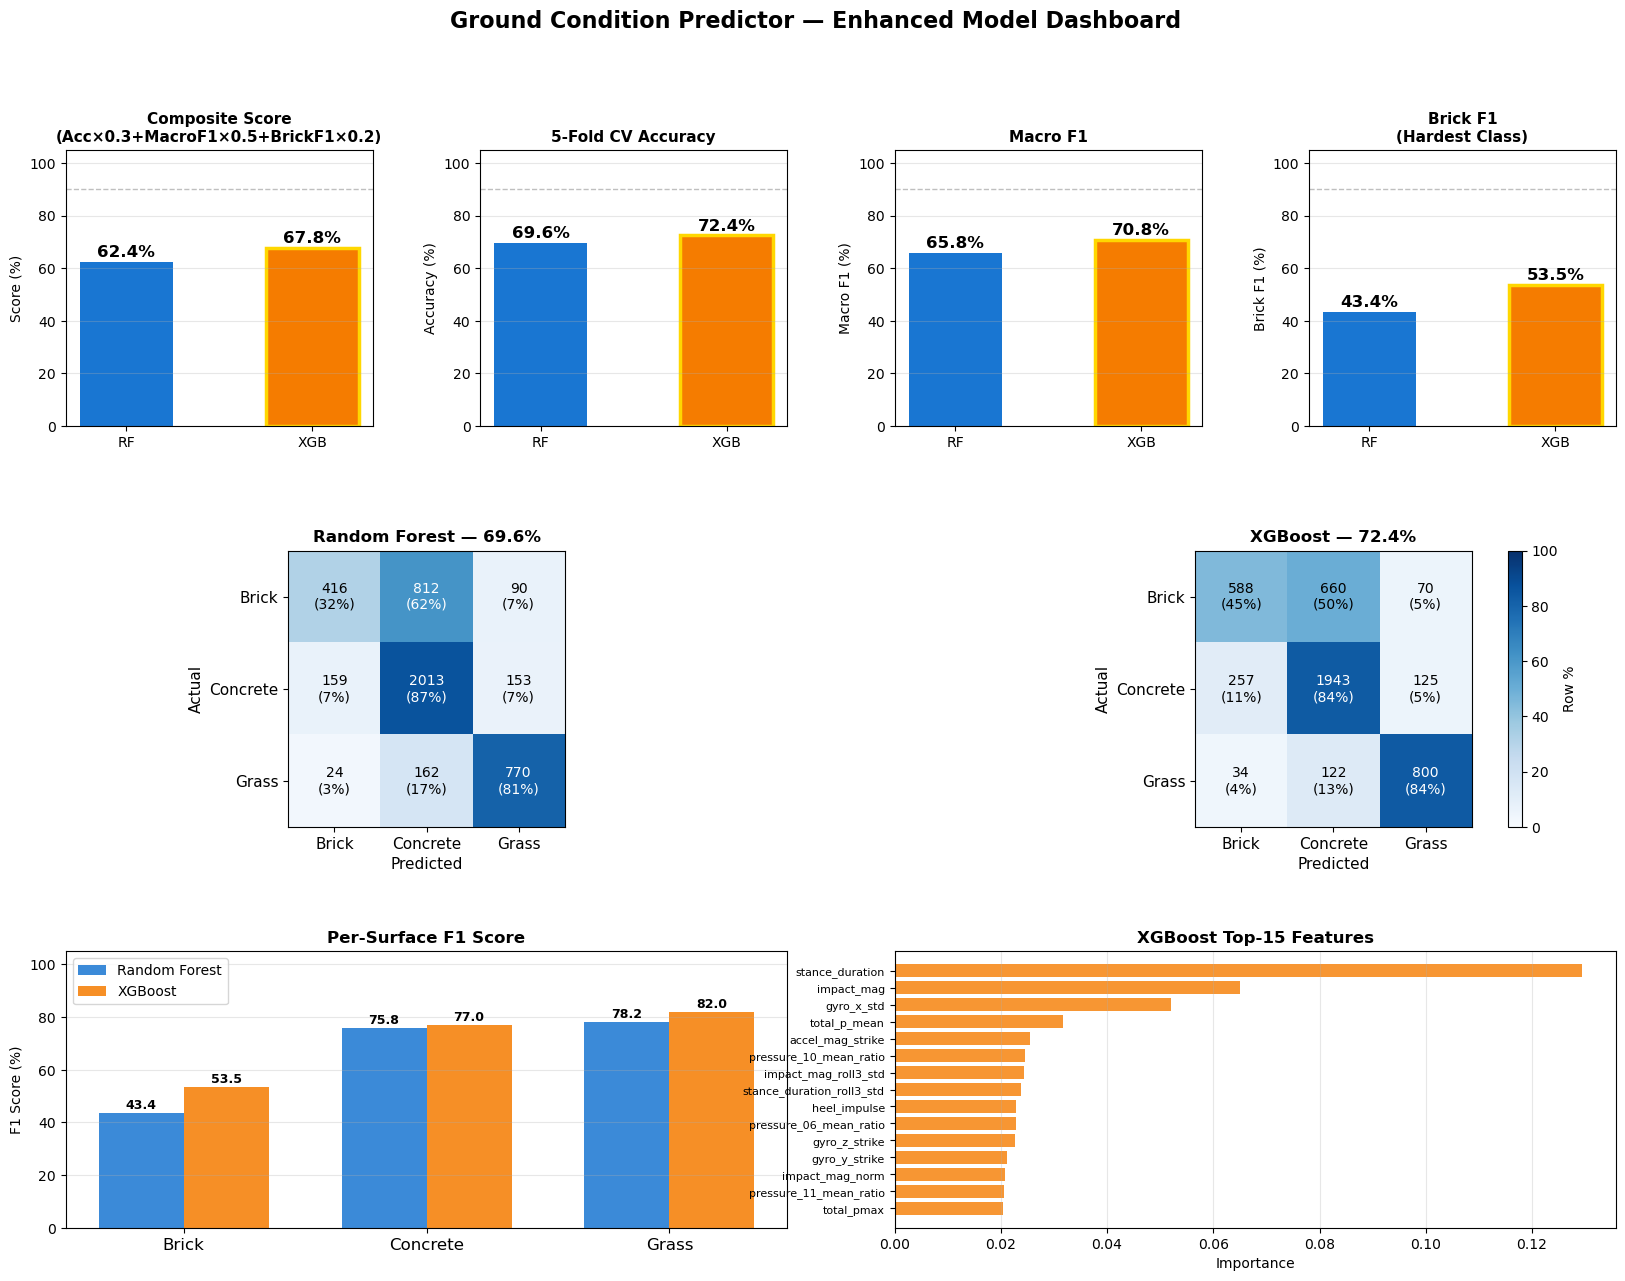


── XGBoost Classification Report ──
              precision    recall  f1-score   support

       brick      0.669     0.446     0.535      1318
    concrete      0.713     0.836     0.770      2325
       grass      0.804     0.837     0.820       956

    accuracy                          0.724      4599
   macro avg      0.729     0.706     0.708      4599
weighted avg      0.719     0.724     0.713      4599



In [7]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Ground Condition Predictor — Enhanced Model Dashboard',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

def score_bar(ax, rf_val, xgb_val, title, ylabel):
    vals  = [rf_val*100, xgb_val*100]
    bars  = ax.bar(['RF','XGB'], vals, color=['#1976D2','#F57C00'], width=0.5)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_ylim(0, 105); ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10); ax.grid(axis='y', alpha=0.3)
    ax.axhline(90, color='gray', ls='--', lw=1, alpha=0.5)
    winner_idx = 1 if xgb_val >= rf_val else 0
    bars[winner_idx].set_edgecolor('gold'); bars[winner_idx].set_linewidth(2.5)

# Row 0: four summary bars
score_bar(fig.add_subplot(gs[0,0]), cs_rf,             cs_xgb,             'Composite Score\n(Acc×0.3+MacroF1×0.5+BrickF1×0.2)', 'Score (%)')
score_bar(fig.add_subplot(gs[0,1]), acc_rf,            acc_xgb,            '5-Fold CV Accuracy', 'Accuracy (%)')
score_bar(fig.add_subplot(gs[0,2]), mf1_rf,            mf1_xgb,            'Macro F1', 'Macro F1 (%)')
score_bar(fig.add_subplot(gs[0,3]), f1_rf[brick_idx],  f1_xgb[brick_idx],  'Brick F1\n(Hardest Class)', 'Brick F1 (%)')

# Row 1: confusion matrices (row-normalised)
for col_pos, y_cv, title, acc in [
    (slice(0,2), y_cv_rf,         f'Random Forest — {acc_rf*100:.1f}%', acc_rf),
    (slice(2,4), y_cv_xgb_labels, f'XGBoost — {acc_xgb*100:.1f}%',     acc_xgb)
]:
    ax = fig.add_subplot(gs[1, col_pos])
    cm = confusion_matrix(y_tr, y_cv, labels=classes)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(classes))); ax.set_xticklabels([c.capitalize() for c in classes], fontsize=11)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels([c.capitalize() for c in classes], fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f'{cm[i,j]}\n({cm_n[i,j]:.0f}%)', ha='center', va='center',
                    color='white' if cm_n[i,j]>55 else 'black', fontsize=10)
plt.colorbar(im, ax=fig.axes[-1], label='Row %')

# Row 2: per-surface F1 grouped bar + XGB feature importance
ax_f1 = fig.add_subplot(gs[2, :2])
x = np.arange(len(classes)); width=0.35
b_rf  = ax_f1.bar(x-width/2, f1_rf*100,  width, label='Random Forest', color='#1976D2', alpha=0.85)
b_xgb = ax_f1.bar(x+width/2, f1_xgb*100, width, label='XGBoost',       color='#F57C00', alpha=0.85)
for bars_ in [b_rf, b_xgb]:
    for bar in bars_:
        ax_f1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_f1.set_xticks(x); ax_f1.set_xticklabels([c.capitalize() for c in classes], fontsize=12)
ax_f1.set_ylabel('F1 Score (%)'); ax_f1.set_ylim(0, 105)
ax_f1.set_title('Per-Surface F1 Score', fontweight='bold', fontsize=12)
ax_f1.legend(fontsize=10); ax_f1.grid(axis='y', alpha=0.3)

ax_fi = fig.add_subplot(gs[2, 2:])
xgb_imp = xgb_pipe.named_steps['xgb'].feature_importances_
top_n   = 15; top_idx = np.argsort(xgb_imp)[::-1][:top_n]
ax_fi.barh(range(top_n), xgb_imp[top_idx][::-1], color='#F57C00', alpha=0.8)
ax_fi.set_yticks(range(top_n))
ax_fi.set_yticklabels([FEATURE_COLS[i] for i in top_idx[::-1]], fontsize=8)
ax_fi.set_xlabel('Importance')
ax_fi.set_title('XGBoost Top-15 Features', fontweight='bold', fontsize=12)
ax_fi.grid(axis='x', alpha=0.3)

plt.savefig('dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n── XGBoost Classification Report ──')
print(classification_report(y_tr, y_cv_xgb_labels, digits=3))

## 6. Feature Distributions by Surface

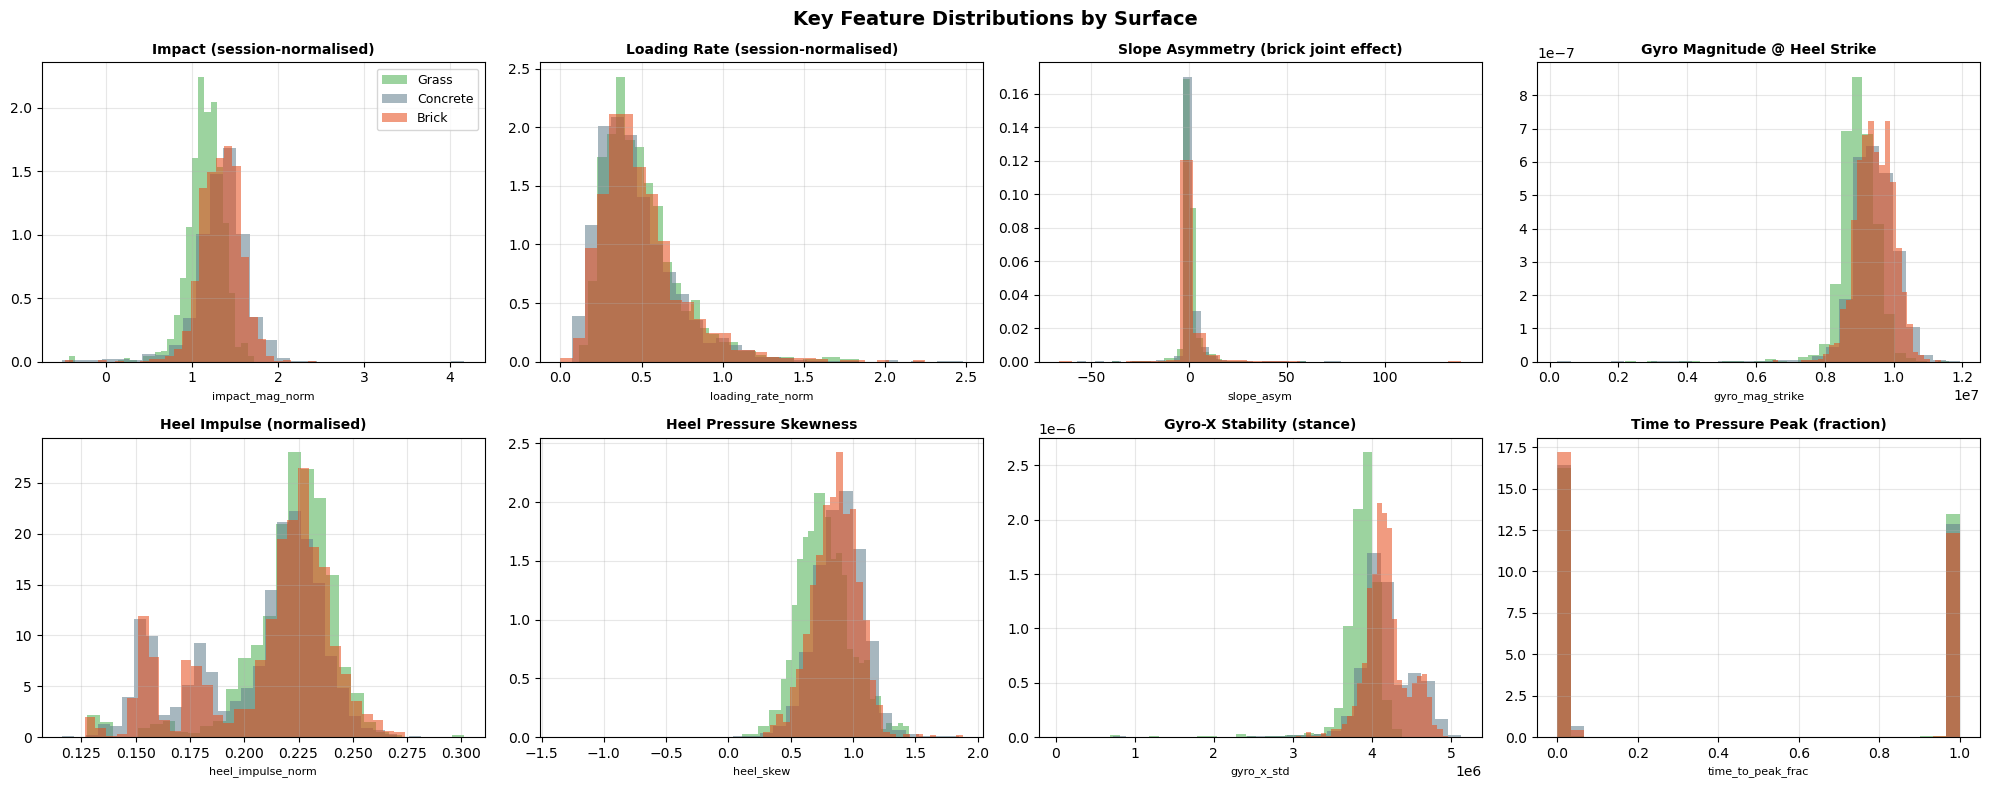

In [8]:
key_feats = ['impact_mag_norm','loading_rate_norm','slope_asym','gyro_mag_strike',
             'heel_impulse_norm','heel_skew','gyro_x_std','time_to_peak_frac']
feat_labels = ['Impact (session-normalised)','Loading Rate (session-normalised)',
               'Slope Asymmetry (brick joint effect)','Gyro Magnitude @ Heel Strike',
               'Heel Impulse (normalised)','Heel Pressure Skewness',
               'Gyro-X Stability (stance)','Time to Pressure Peak (fraction)']

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 8))
fig2.suptitle('Key Feature Distributions by Surface', fontsize=14, fontweight='bold')
for ax, feat, label in zip(axes2.flat, key_feats, feat_labels):
    for surf in ['grass', 'concrete', 'brick']:
        vals = train_df[train_df['surface']==surf][feat].dropna()
        ax.hist(vals, bins=30, alpha=0.55, color=SURFACE_COLORS[surf],
                label=surf.capitalize(), density=True)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel(feat, fontsize=8); ax.grid(alpha=0.3)
    if feat == key_feats[0]:
        ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Predict on New CSV + Sequence Smoothing

In [9]:
NEW_CSV_PATH = 'REC_20260810_144155.csv'   # ← change as needed

print(f'Loading: {NEW_CSV_PATH}  |  Model: {best_name}')
new_raw = pd.read_csv(NEW_CSV_PATH, low_memory=False)
ss_new  = compute_session_stats(new_raw)

pred_frames = []
for sole_id, foot in [(1,'right'), (2,'left')]:
    sub = new_raw[new_raw['sole_id'] == sole_id].copy()
    labelled = label_surface_segments(sub)
    df_proc  = preprocess(labelled if labelled is not None else sub)
    feats = extract_step_features(df_proc, foot_label=foot, session_stats=ss_new)
    if len(feats):
        pred_frames.append(feats)
        print(f'  {foot}: {len(feats)} steps')

pred_df = pd.concat(pred_frames, ignore_index=True)
X_pred  = pred_df[FEATURE_COLS].fillna(0).values

if use_encoded:
    pred_df['predicted_surface'] = le.inverse_transform(best_pipe.predict(X_pred))
    proba = best_pipe.predict_proba(X_pred)
else:
    pred_df['predicted_surface'] = best_pipe.predict(X_pred)
    proba = best_pipe.predict_proba(X_pred)

for i, c in enumerate(classes): pred_df[f'prob_{c}'] = proba[:, i]
pred_df['max_confidence'] = proba.max(axis=1)

# Sequence smoothing
pred_df['smoothed_surface'] = pred_df.groupby('foot')['predicted_surface'].transform(
    lambda s: rolling_majority(s, window=5)
)

print(f'\nRaw predictions:')
print(pred_df.groupby(['foot','predicted_surface']).size().unstack(fill_value=0))
print(f'\nSmoothed predictions:')
print(pred_df.groupby(['foot','smoothed_surface']).size().unstack(fill_value=0))
print(f'\nMean confidence: {pred_df["max_confidence"].mean()*100:.1f}%')

Loading: REC_20260810_144155.csv  |  Model: XGBoost
  right: 307 steps
  left: 308 steps

Raw predictions:
predicted_surface  brick  concrete
foot                              
left                  17       291
right                  3       304

Smoothed predictions:
smoothed_surface  concrete
foot                      
left                   308
right                  307

Mean confidence: 79.3%


## 8. Prediction Visualisation (Raw vs Smoothed)

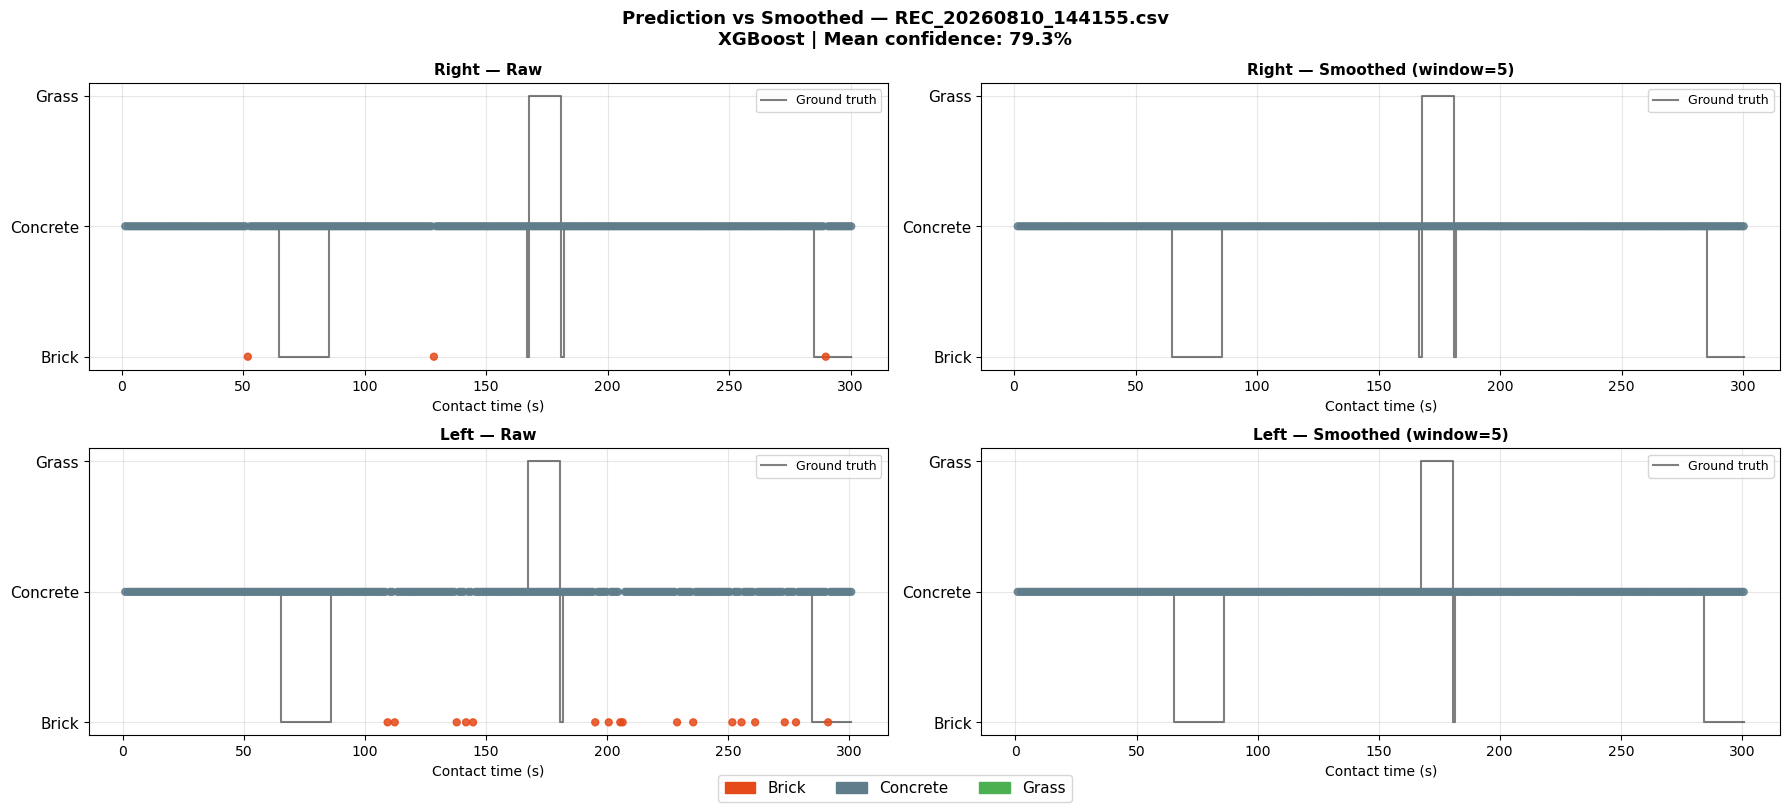

In [10]:
surf_to_int = {s: i for i, s in enumerate(classes)}
int_to_surf = {i: s for s, i in surf_to_int.items()}

fig3, axes3 = plt.subplots(2, 2, figsize=(18, 8))
fig3.suptitle(
    f'Prediction vs Smoothed — {NEW_CSV_PATH}\n'
    f'{best_name} | Mean confidence: {pred_df["max_confidence"].mean()*100:.1f}%',
    fontsize=13, fontweight='bold'
)
for ri, foot in enumerate(['right', 'left']):
    sub = pred_df[pred_df['foot'] == foot].reset_index(drop=True)
    x_ax = sub['contact_time_sec'].values
    for ci, (col, title) in enumerate([
        ('predicted_surface', f'{foot.capitalize()} — Raw'),
        ('smoothed_surface',  f'{foot.capitalize()} — Smoothed (window=5)')
    ]):
        ax = axes3[ri, ci]
        vals = sub[col].map(surf_to_int).values
        colors_plot = [SURFACE_COLORS.get(int_to_surf.get(v,'unknown'),'#9E9E9E') for v in vals]
        ax.scatter(x_ax, vals, c=colors_plot, s=25, alpha=0.85, zorder=3)
        if 'surface' in sub.columns:
            gt = sub['surface'].map(surf_to_int)
            ax.step(x_ax, gt.values, where='post', color='black', lw=1.5,
                    alpha=0.5, label='Ground truth')
            ax.legend(fontsize=9)
        ax.set_yticks(list(surf_to_int.values()))
        ax.set_yticklabels([c.capitalize() for c in classes], fontsize=11)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel('Contact time (s)'); ax.grid(alpha=0.3)

patches = [plt.Rectangle((0,0),1,1,color=SURFACE_COLORS[s]) for s in classes]
fig3.legend(patches, [c.capitalize() for c in classes], loc='lower center',
            ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('sequence_smoothing.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Export Predictions

In [11]:
out_path = 'predictions/' + NEW_CSV_PATH.replace('.csv', f'_predictions_v2.csv')
pred_df[['foot','step_id','contact_time_sec','stance_duration',
         'impact_mag','loading_rate','predicted_surface','smoothed_surface','max_confidence']
       + [f'prob_{c}' for c in classes]
       ].to_csv(out_path, index=False)
print(f'Saved → {out_path}')

Saved → predictions/REC_20260810_144155_predictions_v2.csv
